## State Schema with DataClasses

When we define a LangGraph StateGraph, we use a state schema.

The state shcma represents the structure and types of data that out graph will use.

All nodes are expected to communicate with that schema.

LangGraph offers flexibility in how you define your state schema, acommodating various Python types and validation approches!

As we mentioned in Module 1, we can use the TypedDict class from python's typing module.

It allows you to spcify keys and their corresponding value types.

But, note that there are type hints.

Thye can be used by static type checkers (like mypy) or IDEs to catch potential type-related errors before the code is run.

But they are not enforced at runtime!

In [1]:
from typing_extensions import TypedDict
from typing import Literal

class TypedDictState(TypedDict):
    name: str
    game: Literal["soccer", "baseball"]

In [38]:
def play_game(state: TypedDictState):
    print("---Play Game node has been called---")
    return {"name": state['name'] + " want to play"}

In [39]:
def play_soccer(state: TypedDictState):
    print("---Soccer node has been called---")
    return {"name": state["name"] + " Soccer", "game": "Soccer"}

In [40]:
def play_baseball(state: TypedDictState):
    print("---Baseball node has been called---")
    return {"name": state["name"] + " Baseball", "game": "Baseball"}

In [8]:
import random
def decide_play(state: TypedDictState) -> Literal["soccer", "baseball"]:
    if random.random() < 0.5:
        return "soccer"
    else:
        return "baseball"

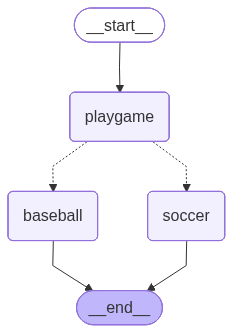

In [ ]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(TypedDictState)
builder.add_node("playgame", play_game)
builder.add_node("soccer", play_soccer)
builder.add_node("baseball", play_baseball)

## Flow of the Graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("soccer", END)
builder.add_edge("baseball", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [43]:
graph.invoke({"name": "Luis"})

---Play Game node has been called---
---Baseball node has been called---


{'name': 'Luis want to play Baseball', 'game': 'Baseball'}

In [37]:
graph.invoke({"name": 123})

---Play Game node has been called---
---Soccer node has been called---


{'name': 123, 'game': 'Soccer'}

### Dataclasses

Python's dataclasses provide another way to define structured data.

Dataclassses offer a concise syntax for creating classes that are primarily used to store data.

In [46]:
### DataClasses
from dataclasses import dataclass

@dataclass
class DataClassState():
    name: str
    game: Literal["soccer", "baseball"]

In [47]:
def play_game(state: DataClassState):
    print("---Play Game node has been called---")
    return {"name": state.name + " want to play"}

def play_soccer(state: DataClassState):
    print("---Soccer node has been called---")
    return {"name": state.name + " Soccer", "game": "Soccer"}

def play_baseball(state: DataClassState):
    print("---Baseball node has been called---")
    return {"name": state.name + " Baseball", "game": "Baseball"}

In [48]:
import random
def decide_play(state: DataClassState) -> Literal["soccer", "baseball"]:
    if random.random() < 0.5:
        return "soccer"
    else:
        return "baseball"

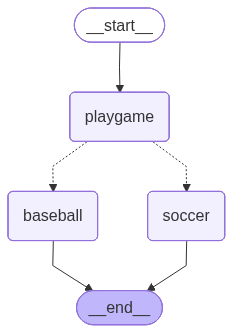

In [49]:
from IPython.display import Image, display
from langgraph.graph import StateGraph, START, END

builder = StateGraph(DataClassState)
builder.add_node("playgame", play_game)
builder.add_node("soccer", play_soccer)
builder.add_node("baseball", play_baseball)

## Flow of the Graph
builder.add_edge(START, "playgame")
builder.add_conditional_edges("playgame", decide_play)
builder.add_edge("soccer", END)
builder.add_edge("baseball", END)

# Add
graph = builder.compile()

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [75]:
graph.invoke(DataClassState(name="Luis", game="soccer"))

---Play Game node has been called---
---Baseball node has been called---


{'name': 'Luis want to play Baseball', 'game': 'Baseball'}